In [1]:
import warnings
warnings.filterwarnings('ignore')


# Data Loading

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test_ = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [3]:
# Train အတွက်
df = df.replace({
    'Yes': 1,
    'No phone service': 0,
    'No': 0,
    'No internet service': 0
})

# Test 
test_ = test_.replace({
    'Yes': 1,
    'No phone service': 0,
    'No': 0,
    'No internet service': 0
})

In [4]:
target = df['Churn']
df.drop(columns=['Churn'],inplace=True)

In [5]:
train_id = df['id']
df.drop(columns=['id','gender'], inplace=True)

test_id = test_['id']
test_.drop(columns=['id','gender'], inplace=True)

# Feature Engineering

In [6]:
services = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


In [7]:
def remaining_contract(row):
    if row['Contract'] == 'One year':
        return max(0, 12 - row['tenure'])
    elif row['Contract'] == 'Two year':
        return max(0, 24 - row['tenure'])
    else:
        return 0 # Month-to-month သမားတွေအတွက်

In [8]:
df['promote'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])
df_remain_contract = df.apply(remaining_contract, axis=1)
test_['promote'] = test_['TotalCharges'] - (test_['MonthlyCharges'] * test_['tenure'])
test_remain_contract = test_.apply(remaining_contract, axis=1)

df['Contract'] = df['Contract'].replace({
    'Month-to-month': 1,
    'One year': 12,
    'Two year': 24
})

test_['Contract'] = test_['Contract'].replace({
    'Month-to-month': 1,
    'One year': 12,
    'Two year': 24
})

df['remian_contract_protion'] = df_remain_contract.replace(0,0.000001)/df['Contract']
test_['remian_contract_protion'] = test_remain_contract.replace(0,0.000001)/test_['Contract']

In [9]:
df['services'] = df[services].sum(axis=1)
test_['services'] = test_[services].sum(axis=1)

df['avg'] = df['MonthlyCharges']/df['services'].replace(0,0.1)
test_['avg'] = test_['MonthlyCharges']/test_['services'].replace(0,0.1)

In [10]:
#train_avg = df[services].multiply(df['avg'], axis=0)
#mu_train = train_avg.mean(axis=0) 
#df['user_cost_differ'] = (train_avg - mu_train).sum(axis=1)

In [11]:
#test_avg_matrix = test_[services].multiply(test_['avg'], axis=0)
#test_['user_cost_differ'] = (test_avg_matrix - mu_train).sum(axis=1)

In [12]:
df = pd.get_dummies(df,drop_first=True).astype('float32')
test_ = pd.get_dummies(test_,drop_first=True).astype('float32')

In [13]:
# အားလုံးပြီးရင် RAM ရှင်းအောင် Garbage Collector ခေါ်ပါ
# to clear RAM
import gc
gc.collect()

0

In [14]:
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,promote,remian_contract_protion,services,avg,InternetService_DSL,InternetService_Fiber optic,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,1.0,...,1653.849976,-89.050003,8.333333e-08,4.0,15.025000,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,1.0,58.0,1.0,0.0,1.0,1.0,0.0,1.0,...,3778.199951,-252.800003,4.166667e-08,5.0,13.900000,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,58.0,1.0,1.0,0.0,1.0,0.0,0.0,...,5841.350098,18.150000,1.000000e-06,5.0,20.080000,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,70.699997,1.000000,1.000000e-06,1.0,69.699997,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,70.449997,0.000000,1.000000e-06,1.0,70.449997,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0.0,0.0,0.0,57.0,1.0,1.0,0.0,0.0,1.0,0.0,...,5460.700195,-99.650002,4.166667e-08,5.0,19.510000,0.0,1.0,0.0,0.0,0.0
594190,0.0,0.0,0.0,72.0,1.0,1.0,1.0,1.0,1.0,1.0,...,6782.149902,161.750000,4.166667e-08,8.0,11.493750,1.0,0.0,0.0,0.0,0.0
594191,0.0,1.0,0.0,72.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1871.900024,115.099998,4.166667e-08,2.0,12.200000,0.0,0.0,1.0,0.0,0.0
594192,0.0,0.0,0.0,32.0,1.0,1.0,0.0,0.0,0.0,0.0,...,2847.199951,95.199997,1.000000e-06,3.0,28.666666,0.0,1.0,0.0,1.0,0.0


# Model and training

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [16]:
# XGB model
model = XGBClassifier(
    learning_rate=0.02,
    tree_method='hist',
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.4,
    n_estimators=3300,
    max_depth=6,
    gamma=0.3,
    min_child_weight=6,
    device='cuda',
    early_stopping_rounds=100,
    reg_alpha=3
)

# Initialize placeholders for predictions
# oof_preds: To store predictions for the training set (to check CV score)
oof_preds = np.zeros(len(df)) 
# test_preds_total: To store the average predictions for the test set (for submission)
test_preds_total = np.zeros(len(test_))
# Initialize the S-KFold strategy
n_s = 12
skf = StratifiedKFold(n_splits=n_s, shuffle=True, random_state=42)

# Start the Cross-Validation Loop
# We split the data into 5 parts and train 5 different models
# This loop ensures every data point in the training set is used for validation once
for fold, (train_idx, val_idx) in enumerate(skf.split(df, target)):
    X_train, X_val = df.iloc[train_idx], df.iloc[val_idx]
    y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=0
    )
    
    pre_y_xgb = model.predict_proba(X_val)[:, 1]
    print(f'Score of Fold {fold} XGB: {roc_auc_score(y_val,pre_y_xgb):.5f} %')

    

    test_preds_total += model.predict_proba(test_)[:, 1]/n_s
    oof_preds[val_idx] = pre_y_xgb
    print(f"Fold {fold} finished.")



Score of Fold 0 XGB: 0.91719 %
Fold 0 finished.
Score of Fold 1 XGB: 0.91640 %
Fold 1 finished.
Score of Fold 2 XGB: 0.91870 %
Fold 2 finished.
Score of Fold 3 XGB: 0.91414 %
Fold 3 finished.
Score of Fold 4 XGB: 0.91811 %
Fold 4 finished.
Score of Fold 5 XGB: 0.91651 %
Fold 5 finished.
Score of Fold 6 XGB: 0.91684 %
Fold 6 finished.
Score of Fold 7 XGB: 0.91868 %
Fold 7 finished.
Score of Fold 8 XGB: 0.91644 %
Fold 8 finished.
Score of Fold 9 XGB: 0.91813 %
Fold 9 finished.
Score of Fold 10 XGB: 0.91658 %
Fold 10 finished.
Score of Fold 11 XGB: 0.91388 %
Fold 11 finished.


In [17]:
from sklearn.metrics import roc_auc_score

print(f'XGB Train score:{roc_auc_score(target,oof_preds):.5f}')

XGB Train score:0.91680


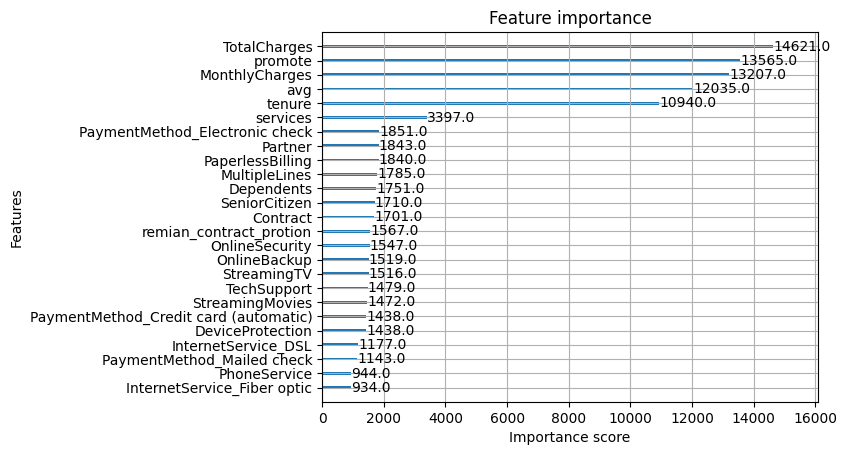

In [18]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
# this will show feature importance of the last model in skf loop
plot_importance(model)
plt.show()

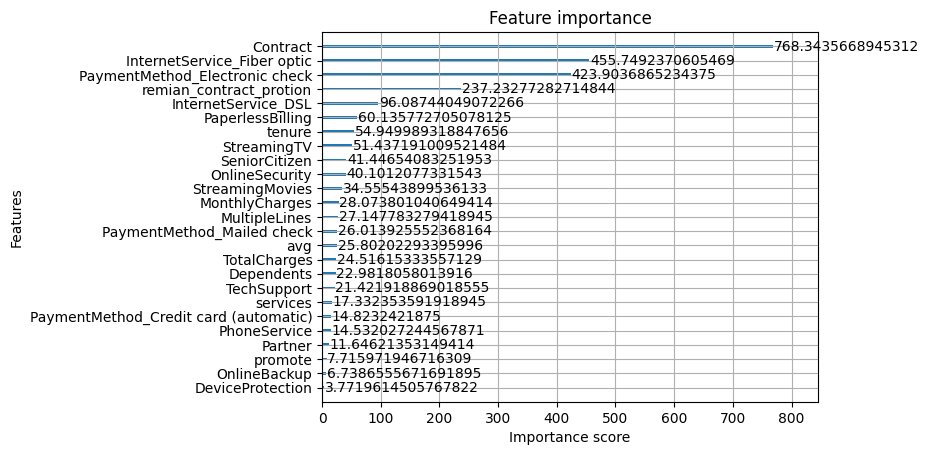

In [19]:
plot_importance(model,importance_type='gain')
plt.show()

# Submission

In [20]:
preditions = test_preds_total

In [21]:
output = pd.DataFrame({
   'id': test_id,
   'Churn': preditions
})

output.to_csv('submission.csv',index=False)